In [5]:
import yfinance as yf
import numpy as np
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Descargar datos del subyacente
ticker = yf.Ticker('MSFT')

#Precio spot actual
hist_spot = ticker.history(period='1d')
S0 = hist_spot['Close'].iloc[-1]
print(f' Precio spot MSFT ($S_0$): ${S0:.2f}')

#vencimiento entre 30 y 90 días
from datetime import datetime, timedelta

hoy = datetime.today()
vencimientos = ticker.options  # lista de strings 'YYYY-MM-DD'

#Filtrar vencimientos en la ventana [30, 90] días
opciones_validas = [
    v for v in vencimientos
    if 30 <= (datetime.strptime(v, '%Y-%m-%d') - hoy).days <= 90
]

#Si no hay en esa ventana, tomar el más cercano disponible
if not opciones_validas:
    opciones_validas = [vencimientos[1] if len(vencimientos) > 1 else vencimientos[0]]

fecha_exp = opciones_validas[0]
T = (datetime.strptime(fecha_exp, '%Y-%m-%d') - hoy).days / 365
print(f' Fecha de vencimiento seleccionada: {fecha_exp}  (T = {T:.4f} años)')

#Extraer cadena de opciones Call
chain = ticker.option_chain(fecha_exp)
calls_raw = chain.calls.copy()

print(f'\n Contratos Call disponibles: {len(calls_raw)}')
print(f'Columnas disponibles: {list(calls_raw.columns)}')
calls_raw.head(3)

#Parámetros del modelo
r = 0.045      
q = 0.0075     

#Limpieza de la cadena de opciones
df = calls_raw[[
    'strike', 'bid', 'ask', 'lastPrice',
    'impliedVolatility', 'volume', 'openInterest'
]].copy()

#Calcular Mid-Price (precio real de referencia)
df['midPrice'] = (df['bid'] + df['ask']) / 2

#Filtrar contratos sin liquidez real
df = df[
    (df['bid'] > 0) &
    (df['impliedVolatility'] > 0.01) &
    (df['impliedVolatility'] < 3.0) &    # eliminar valores extremos
    (df['volume'] > 0)
].reset_index(drop=True)

#Variables de entrada para ML
df['Moneyness'] = df['strike'] / S0          # K/S_t
df['T'] = T                                   # Tiempo a vencimiento (constante para este cross-section)
df['log_Moneyness'] = np.log(df['Moneyness']) # log(K/S) 

#Variable objetivo
df['IV_mercado'] = df['impliedVolatility']



print(f'Contratos útiles tras filtrado: {len(df)}')
print(f'Moneyness rango: [{df.Moneyness.min():.3f}, {df.Moneyness.max():.3f}]')
print(f'IV mercado rango: [{df.IV_mercado.min():.2%}, {df.IV_mercado.max():.2%}]')
print()


df.to_csv('opciones_msft_procesado.csv', index=False)

 Precio spot MSFT ($S_0$): $370.45
 Fecha de vencimiento seleccionada: 2026-07-31  (T = 0.0986 años)

 Contratos Call disponibles: 54
Columnas disponibles: ['contractSymbol', 'lastTradeDate', 'strike', 'lastPrice', 'bid', 'ask', 'change', 'percentChange', 'volume', 'openInterest', 'impliedVolatility', 'inTheMoney', 'contractSize', 'currency']
Contratos útiles tras filtrado: 54
Moneyness rango: [0.729, 1.566]
IV mercado rango: [42.49%, 72.71%]



In [6]:
df_ops = pd.read_csv('opciones_msft_procesado.csv')
df_ops[['strike', 'Moneyness', 'log_Moneyness', 'midPrice', 'IV_mercado']].head(8)

,strike,Moneyness,log_Moneyness,midPrice,IV_mercado
0,270.0,0.728843,-0.316297,103.525,0.727054
1,280.0,0.755837,-0.279929,93.450,0.656498
2,290.0,0.782832,-0.244838,84.025,0.622074
3,300.0,0.809826,-0.210936,74.550,0.580571
4,305.0,0.823323,-0.194407,70.025,0.567143
5,310.0,0.836820,-0.178146,65.175,0.539311
6,315.0,0.850317,-0.162146,60.800,0.528386
7,320.0,0.863814,-0.146398,56.150,0.505681


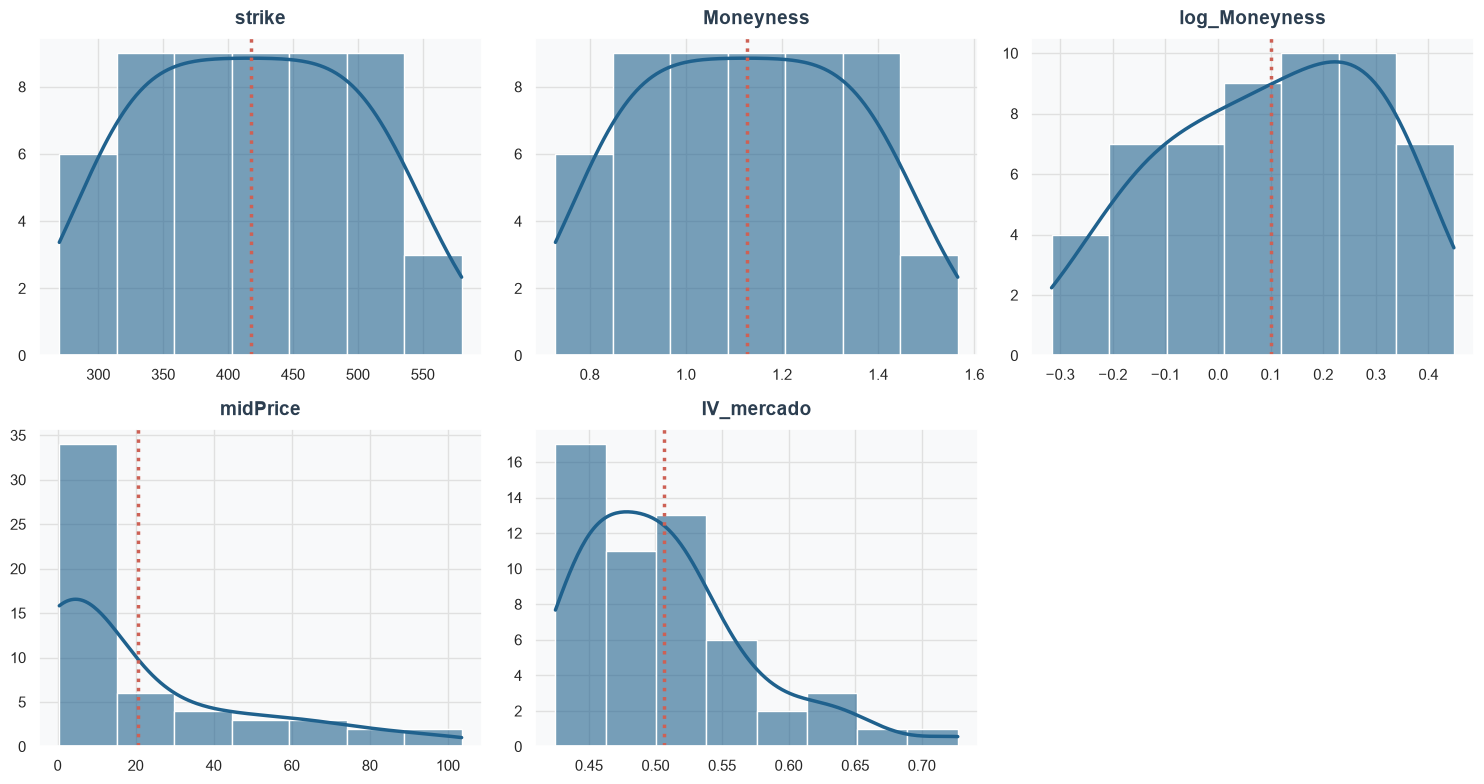

In [7]:
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_selec = df_ops[['strike', 'Moneyness', 'log_Moneyness', 'midPrice', 'IV_mercado']]

sns.set_theme(style="darkgrid", rc={"grid.color": "#e0e0e0", "axes.facecolor": "#f8f9fa"})

cols = 3  
rows = math.ceil(df_selec.shape[1] / cols) 
plt.figure(figsize=(15, rows * 4))


for index, (colname, serie) in enumerate(df_selec.items()):
    plt.subplot(rows, cols, index + 1)
    if pd.api.types.is_float_dtype(serie) is True :
        sns.histplot(serie, kde=True, color="#1f618d", alpha=0.6, line_kws={"linewidth": 2.5, "color": "#117a65"})
        plt.axvline(np.mean(serie), color='#cd6155', linestyle=':', linewidth=2.5)
    elif pd.api.types.is_integer_dtype(serie) is True :
        sns.countplot(x=serie, color='#1f618d')
    
    plt.title(colname, fontsize=14, fontweight='bold', color='#2c3e50', pad=10)
    plt.xlabel( '' ); plt.ylabel( '' ); plt.tight_layout()



plt.show()

In [8]:
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

--- MÁTRICAS DE EVALUACIÓN DEL SVR ---
Error Cuadrático Medio Numérico (RMSE): 1.6737
Coeficiente de Determinación (R²): 0.9957
R² de Entrenamiento: 0.9936
R² de Prueba: 0.9957


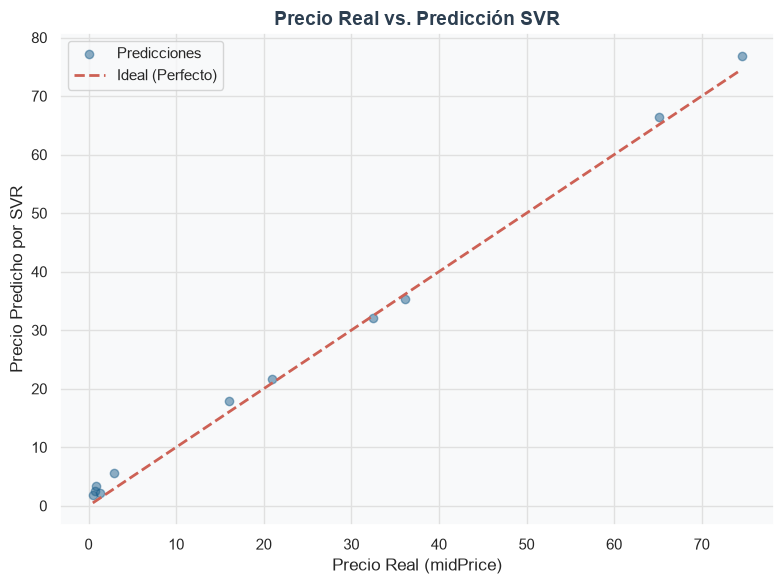

In [ ]:
X = df_selec[['strike', 'Moneyness', 'log_Moneyness']]
y = df_selec['midPrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler_X = StandardScaler()
scaler_y = StandardScaler()

#escalar los datos de entrada y salida
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).flatten()

#entrenar el modelo SVR con kernel RBF

svr_model = SVR(kernel='rbf', C=10.0, epsilon=0.1, gamma='scale')
svr_model.fit(X_train_scaled, y_train_scaled)

#realizar predicciones
y_pred_scaled = svr_model.predict(X_test_scaled)

#desescalar las predicciones para volver a los precios reales en dolares
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

#evaluar la calidad del modelo
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("--- MÁTRICAS DE EVALUACIÓN DEL SVR ---")
print(f"Error Cuadrático Medio Numérico (RMSE): {rmse:.4f}")
print(f"Coeficiente de Determinación (R²): {r2:.4f}")


#grafico de dispersión de los precios reales vs. predicciones del modelo SVR
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='#1f618d', alpha=0.5, label='Predicciones')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='#cd6155', linestyle='--', linewidth=2, label='Ideal (Perfecto)')
plt.title('Precio Real vs. Predicción SVR', fontsize=14, fontweight='bold', color='#2c3e50')
plt.xlabel('Precio Real (midPrice)')
plt.ylabel('Precio Predicho por SVR')
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
#prueba en caso de overffitting: Calcular R² en los mismos datos con los que estudió
y_pred_train_scaled = svr_model.predict(X_train_scaled)
r2_train = r2_score(y_train_scaled, y_pred_train_scaled)

print(f"R² de Entrenamiento: {r2_train:.4f}")
print(f"R² de Prueba: {r2:.4f}") # El que ya tienes

R² de Entrenamiento: 0.9936
R² de Prueba: 0.9957
